In [64]:
import os, json, time, warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from PIL import Image, UnidentifiedImageError
from typing import Dict, Tuple, List

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.cuda.amp import GradScaler, autocast
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import models, transforms
import torchvision.utils as vutils

from transformers import DistilBertModel, DistilBertTokenizerFast
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, classification_report, confusion_matrix, accuracy_score

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'  PyTorch: {torch.__version__}')
print(f'  Cihaz  : {DEVICE}')

  PyTorch: 2.10.0+cu128
  Cihaz  : cuda


In [82]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("paramaggarwal/fashion-product-images-dataset")

DATA_DIR = os.path.join(path, 'fashion-dataset')
CSV_PATH = os.path.join(DATA_DIR, 'styles.csv')
IMG_DIR  = os.path.join(DATA_DIR, 'images')

df = pd.read_csv(CSV_PATH, on_bad_lines='skip')
print(f'Rows: {len(df):,}  |  Columns: {list(df.columns)}')
df


Using Colab cache for faster access to the 'fashion-product-images-dataset' dataset.
Rows: 44,424  |  Columns: ['id', 'gender', 'masterCategory', 'subCategory', 'articleType', 'baseColour', 'season', 'year', 'usage', 'productDisplayName']


,id,gender,masterCategory,subCategory,articleType,baseColour,season,year,usage,productDisplayName
0,15970,Men,Apparel,Topwear,Shirts,Navy Blue,Fall,2011.0,Casual,Turtle Check Men Navy Blue Shirt
1,39386,Men,Apparel,Bottomwear,Jeans,Blue,Summer,2012.0,Casual,Peter England Men Party Blue Jeans
2,59263,Women,Accessories,Watches,Watches,Silver,Winter,2016.0,Casual,Titan Women Silver Watch
3,21379,Men,Apparel,Bottomwear,Track Pants,Black,Fall,2011.0,Casual,Manchester United Men Solid Black Track Pants
4,53759,Men,Apparel,Topwear,Tshirts,Grey,Summer,2012.0,Casual,Puma Men Grey T-shirt
...,...,...,...,...,...,...,...,...,...,...
44419,17036,Men,Footwear,Shoes,Casual Shoes,White,Summer,2013.0,Casual,Gas Men Caddy Casual Shoe
44420,6461,Men,Footwear,Flip Flops,Flip Flops,Red,Summer,2011.0,Casual,Lotto Men's Soccer Track Flip Flop
44421,18842,Men,Apparel,Topwear,Tshirts,Blue,Fall,2011.0,Casual,Puma Men Graphic Stellar Blue Tshirt
44422,46694,Women,Personal Care,Fragrance,Perfume and Body Mist,Blue,Spring,2017.0,Casual,Rasasi Women Blue Lady Perfume


In [83]:
df.dtypes

,0
id,int64
gender,object
masterCategory,object
subCategory,object
articleType,object
baseColour,object
season,object
year,float64
usage,object
productDisplayName,object


In [84]:
# hansı sütunlarda boş dəyər var
df.isnull().sum()

,0
id,0
gender,0
masterCategory,0
subCategory,0
articleType,0
baseColour,15
season,21
year,1
usage,317
productDisplayName,7


In [85]:
df.describe()

,id,year
count,44424.000000,44423.000000
mean,29696.334301,2012.806497
std,17049.490518,2.126480
min,1163.000000,2007.000000
25%,14768.750000,2011.000000
50%,28618.500000,2012.000000
75%,44683.250000,2015.000000
max,60000.000000,2019.000000


In [86]:
df['masterCategory'].value_counts()

,count
masterCategory,
Apparel,21397
Accessories,11274
Footwear,9219
Personal Care,2403
Free Items,105
Sporting Goods,25
Home,1


In [87]:
df['subCategory'].value_counts().head(10)

,count
subCategory,
Topwear,15402
Shoes,7343
Bags,3055
Bottomwear,2694
Watches,2542
Innerwear,1808
Jewellery,1079
Eyewear,1073
Fragrance,1011


In [88]:
df['articleType'].value_counts().head(12)

,count
articleType,
Tshirts,7067
Shirts,3217
Casual Shoes,2845
Watches,2542
Sports Shoes,2036
Kurtas,1844
Tops,1762
Handbags,1759
Heels,1323


In [89]:
df['baseColour'].value_counts().head(10)

,count
baseColour,
Black,9728
White,5538
Blue,4918
Brown,3494
Grey,2741
Red,2455
Green,2115
Pink,1860
Navy Blue,1789


In [90]:
#dataset nə vaxtdan var?
df['year'].value_counts().sort_index()

,count
year,
2007.0,2
2008.0,7
2009.0,20
2010.0,846
2011.0,13672
2012.0,16288
2013.0,1212
2014.0,236
2015.0,2780


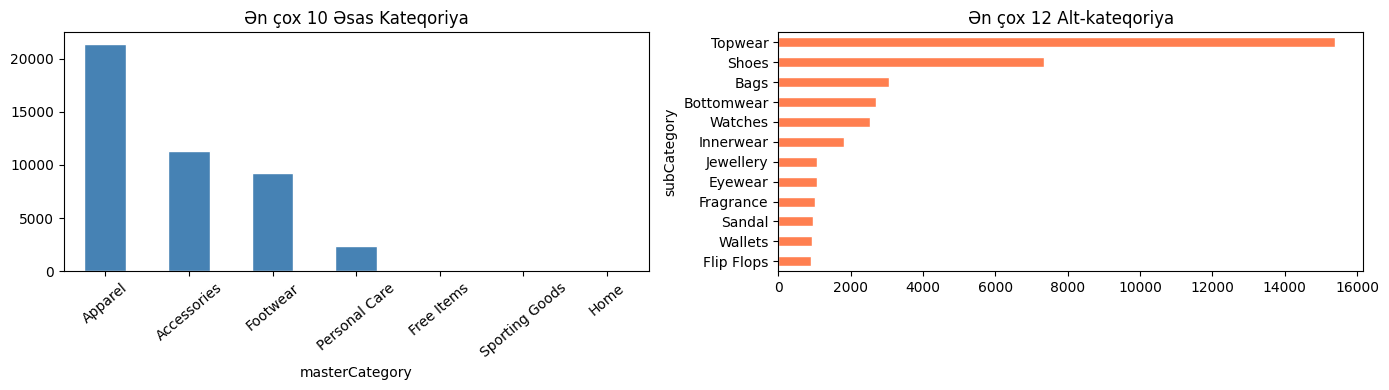

In [91]:
#Kateqoriya paylanması
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

df['masterCategory'].value_counts().head(10).plot.bar(
    ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Ən çox 10 Əsas Kateqoriya', fontsize=12)
axes[0].tick_params(axis='x', rotation=40)

df['subCategory'].value_counts().head(12).plot.barh(
    ax=axes[1], color='coral', edgecolor='white')
axes[1].set_title('Ən çox 12 Alt-kateqoriya', fontsize=12)
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()
#Bu o deməkdir ki, model bu kateqoriyaları çox yaxşı tanıyacaq
#amma azlıqda qalanları (məsələn, Wallets və ya Belts) tanımaqda çətinlik çəkə bilər.

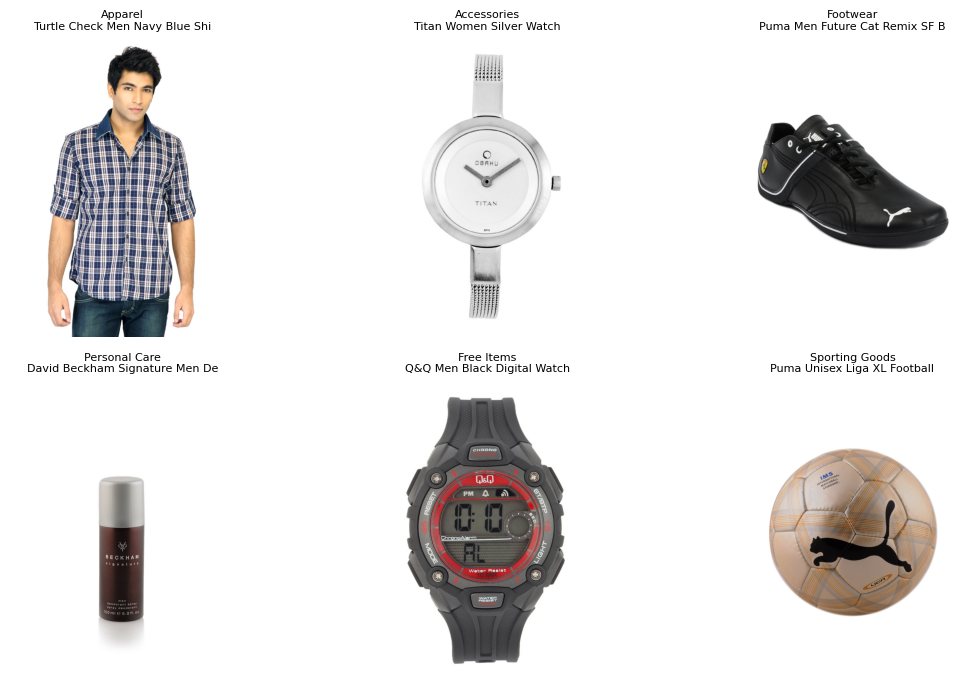

In [92]:
# nümunə şəkillər
cats = df['masterCategory'].value_counts().head(6).index.tolist()
fig, axes = plt.subplots(2, 3, figsize=(12, 7))

for ax, cat in zip(axes.flat, cats):
    sub = df[df['masterCategory'] == cat].dropna(subset=['id'])
    for _, row in sub.iterrows():
        p = os.path.join(IMG_DIR, f"{int(row['id'])}.jpg")
        if os.path.isfile(p):
            ax.imshow(Image.open(p).convert('RGB'))
            ax.set_title(f"{cat}\n{str(row['productDisplayName'])[:30]}", fontsize=8)
            ax.axis('off')
            break

plt.tight_layout()
plt.show()

# Data Cleaning

In [94]:
before = len(df)
df.dropna(subset=['masterCategory'], inplace=True)
print(f'{before - len(df)} sətir (masterCategory boş olanlar)')

0 sətir (masterCategory boş olanlar)


In [95]:
# productDisplayName boşdursa dolduraq
df['productDisplayName'] = df.apply(
    lambda x: f"{x['baseColour']} {x['gender']} {x['articleType']} for {x['usage']}"
    if pd.isna(x['productDisplayName']) else x['productDisplayName'],
    axis=1
)

df['articleType']= df['articleType'].fillna('Unknown')
df['baseColour']= df['baseColour'].fillna('Unknown')

#  həmin 'articleType' üçün ən çox hansı sezon istifadə olunursa
df['season']= df.groupby('articleType')['season'].transform(lambda x: x.fillna(x.mode()[0] if not x.mode().empty else "Unknown"))

df['year'] = df['year'].fillna(df.groupby('masterCategory')['year'].transform('median'))

df.isnull().sum()

,0
id,0
gender,0
masterCategory,0
subCategory,0
articleType,0
baseColour,0
season,0
year,0
usage,317
productDisplayName,0


In [96]:

null_count = df['usage'].isnull().sum()
null_percentage = (null_count / len(df)) * 100

print(f"Usage {null_count} boşluq ")
print(f"datanın {null_percentage:.2f}%-i")

Usage 317 boşluq 
datanın 0.71%-i


In [97]:
# 'articleType' qrupuna görə ən çox rast gəlinən usage dəyəri ilə doldurdum
df['usage'] = df['usage'].fillna(df.groupby('articleType')['usage'].transform(lambda x: x.mode()[0] if not x.mode().empty else "Casual"))

In [98]:
# şəkli olmayan sətirləri çıxaraq
df['image_path'] = df['id'].apply(lambda x: os.path.join(IMG_DIR, f'{x}.jpg'))
before2 = len(df)
df = df[df['image_path'].apply(os.path.isfile)].reset_index(drop=True)
print(f'şəkli yoxdur: {before2 - len(df)} sətir silindi')
print(f'qalan: {len(df)}')

şəkli yoxdur: 5 sətir silindi
qalan: 44419


In [100]:
df.isnull().sum()

,0
id,0
gender,0
masterCategory,0
subCategory,0
articleType,0
baseColour,0
season,0
year,0
usage,0
productDisplayName,0


In [101]:
def build_text(row):
    name       = str(row['productDisplayName']).strip()
    name_lower = name.lower()
    parts      = [name]

    for col in ['articleType', 'baseColour', 'season']:
        val = str(row[col]).strip()
        if val.lower() not in ('nan', 'unknown', '') and val.lower() not in name_lower:
            parts.append(val)

    return ' | '.join(parts)

df['text'] = df.apply(build_text, axis=1)
df[['productDisplayName', 'baseColour', 'text']].head(4)

,productDisplayName,baseColour,text
0,Turtle Check Men Navy Blue Shirt,Navy Blue,Turtle Check Men Navy Blue Shirt | Shirts | Fall
1,Peter England Men Party Blue Jeans,Blue,Peter England Men Party Blue Jeans | Summer
2,Titan Women Silver Watch,Silver,Titan Women Silver Watch | Watches | Winter
3,Manchester United Men Solid Black Track Pants,Black,Manchester United Men Solid Black Track Pants ...


In [17]:
# top-10 kateqoriya saxlayaq
top_cats = df['masterCategory'].value_counts().head(10).index
df = df[df['masterCategory'].isin(top_cats)].copy()

label2id = {c: i for i, c in enumerate(sorted(df['masterCategory'].unique()))}
id2label = {v: k for k, v in label2id.items()}
df['label'] = df['masterCategory'].map(label2id)

print(label2id)
print(f'\ntoplamda: {len(df)}')

{'Accessories': 0, 'Apparel': 1, 'Footwear': 2, 'Free Items': 3, 'Home': 4, 'Personal Care': 5, 'Sporting Goods': 6}

toplamda: 44419


In [18]:
for idx, name in sorted(id2label.items()):
 print(f'  {idx:>2}  {name:<22}  {(df["label"]==idx).sum():>5} nümunə')

   0  Accessories             11274 nümunə
   1  Apparel                 21392 nümunə
   2  Footwear                 9219 nümunə
   3  Free Items                105 nümunə
   4  Home                        1 nümunə
   5  Personal Care            2403 nümunə
   6  Sporting Goods             25 nümunə


In [19]:
TOP_N_CLASSES   = 10
IMG_SIZE      = 224
MAX_LEN    = 64
tokenizer = DistilBertTokenizerFast.from_pretrained('distilbert-base-uncased')
IMG_MEAN   = [0.485, 0.456, 0.406]
IMG_STD    = [0.229, 0.224, 0.225]
#Çünki ResNet-18 ImageNet datasetində təlim keçərkən bu rəqəmlərlə normallaşdırılıbdi

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [20]:
def get_tf(split): #'train' üçün şəkil artırma (augmentation), test üçün yalnız standart hazırlıq.
    if split == 'train':
        return transforms.Compose([
            transforms.Resize((IMG_SIZE + 32, IMG_SIZE + 32)),
           transforms.RandomCrop(IMG_SIZE),       # Mərkəzdən asılılığı qırır
            transforms.RandomHorizontalFlip(p=0.5),  # 50% ehtimalla şəkli güzgü kimi çevirir
            transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2), # İşığı və rəngi dəyişir
            transforms.RandomRotation(10),               # Şəkli maksimum 10 dərəcə döndərir '''

            transforms.ToTensor(),
            transforms.Normalize(IMG_MEAN, IMG_STD),
        ])
    return transforms.Compose([
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize(IMG_MEAN, IMG_STD),
    ])

In [21]:
df.head(3)

,id,gender,masterCategory,subCategory,articleType,baseColour,season,year,usage,productDisplayName,image_path,text,label
0,15970,Men,Apparel,Topwear,Shirts,Navy Blue,Fall,2011.0,Casual,Turtle Check Men Navy Blue Shirt,/kaggle/input/fashion-product-images-dataset/f...,Turtle Check Men Navy Blue Shirt | Shirts | Fall,1
1,39386,Men,Apparel,Bottomwear,Jeans,Blue,Summer,2012.0,Casual,Peter England Men Party Blue Jeans,/kaggle/input/fashion-product-images-dataset/f...,Peter England Men Party Blue Jeans | Summer,1
2,59263,Women,Accessories,Watches,Watches,Silver,Winter,2016.0,Casual,Titan Women Silver Watch,/kaggle/input/fashion-product-images-dataset/f...,Titan Women Silver Watch | Watches | Winter,0


# Preparing for Model

In [22]:
class FashionDataset(Dataset):
    def __init__(self, df, transform):
        self.df  = df.reset_index(drop=True)
        self.tf  = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        try:
            img = Image.open(row['image_path']).convert('RGB')
        except:
            img = Image.new('RGB', (IMG_SIZE, IMG_SIZE), 128)
        img = self.tf(img)

        enc = tokenizer(
            str(row['text']),
            max_length=MAX_LEN,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )

        return {
            'image'         : img,
            'input_ids'     : enc['input_ids'].squeeze(0),
            'attention_mask': enc['attention_mask'].squeeze(0),
            'label'         : torch.tensor(row['label'], dtype=torch.long)
        }

In [23]:
print(df['label'].value_counts())

label
1    21392
0    11274
2     9219
5     2403
3      105
6       25
4        1
Name: count, dtype: int64


In [24]:
df = df[df['label'] != 4]
idx_all = df.index.tolist()
lbl_all = df['label'].tolist()

tr_idx, tmp, _, tmp_lbl = train_test_split(idx_all, lbl_all, test_size=0.3,
                                            stratify=lbl_all, random_state=42)
vl_idx, te_idx = train_test_split(tmp, test_size=0.5, stratify=tmp_lbl, random_state=42)

print(f'train={len(tr_idx)}  val={len(vl_idx)}  test={len(te_idx)}')

train=31092  val=6663  test=6663


In [25]:
# az nümunəli siniflər train-da az görünür
# WeightedRandomSampler bunu balanslaşdırır
tr_labels     = df.loc[tr_idx, 'label'].tolist()
class_counts  = np.bincount(tr_labels)
weights       = 1.0 / class_counts[tr_labels]
sampler       = WeightedRandomSampler(torch.tensor(weights, dtype=torch.double),
                                      num_samples=len(tr_idx), replacement=True)

BS = 32
train_dl = DataLoader(FashionDataset(df.loc[tr_idx], get_tf('train')),
                      batch_size=BS, sampler=sampler, num_workers=2, pin_memory=True)
val_dl   = DataLoader(FashionDataset(df.loc[vl_idx], get_tf('val')),
                      batch_size=BS, shuffle=False,  num_workers=2, pin_memory=True)
test_dl  = DataLoader(FashionDataset(df.loc[te_idx], get_tf('test')),
                      batch_size=BS, shuffle=False,  num_workers=2, pin_memory=True)

# sınaq
b = next(iter(train_dl))
for k, v in b.items():
    print(k, v.shape)

image torch.Size([32, 3, 224, 224])
input_ids torch.Size([32, 64])
attention_mask torch.Size([32, 64])
label torch.Size([32])


In [36]:
class ImageEncoder(nn.Module):
    # erkən qatlar ümumi vizual xüsusiyyətlər öyrənib — onları dondururuq
    # layer3 + layer4 moda-spesifik — onları fine-tune edirik
    def __init__(self, out_dim=512):
        super().__init__()
        base = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)

        for name, p in base.named_parameters():
            if not any(name.startswith(f'layer{i}') for i in [3, 4]):
                p.requires_grad_(False)

        # son FC qatı çıxarırıq
        self.backbone = nn.Sequential(*list(base.children())[:-1])
        self.proj = nn.Sequential(
            nn.Flatten(),
            nn.LayerNorm(512),
            nn.Linear(512, out_dim),
            #nn.GELU()
            nn.ReLU()
        )

    def forward(self, x):
        return self.proj(self.backbone(x))


# sınaq
ie = ImageEncoder()
print(ie(torch.randn(2, 3, 224, 224)).shape)

torch.Size([2, 512])


In [37]:
class TextEncoder(nn.Module):

    #DistilBERT backbone
    #transformer layer 0-4 dondurruq ki ing dilin bos bosuna yox ele terminleri oyrensin
    #transformer layer 5  ÖYRƏNİR  son qat
    #bütün qatları dondururuq, yalnız son transformer qatı öyrənir
    #çünki əvvəlki qatlarda ümumi dil bilikləri var — onları dəyişmək lazım deyil
    def __init__(self, out_dim=512):
        super().__init__()
        self.bert = DistilBertModel.from_pretrained('distilbert-base-uncased')

        for p in self.bert.parameters():
            p.requires_grad_(False)
        for p in self.bert.transformer.layer[-1].parameters():
            p.requires_grad_(True)

        self.proj = nn.Sequential(
            nn.LayerNorm(768),
            nn.Linear(768, out_dim),
            #nn.GELU()
            nn.ReLU()
        )

    def forward(self, input_ids, attention_mask):
        out = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        cls = out.last_hidden_state[:, 0, :]
        return self.proj(cls)


te = TextEncoder()
print(te(torch.randint(0, 100, (2, 64)), torch.ones(2, 64, dtype=torch.long)).shape)

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_transform.weight  | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


torch.Size([2, 512])


## Multi-Model Classifier
Artıq əlimizdə 512 ölçülü Görüntü vektoru və 512 ölçülü Mətn vektoru var. İndi bunları tək bir sey altında, əsas Multi-Modal Classifier klassında birləşdirmək lazimdir

In [38]:
class GatedFusion(nn.Module):
    def __init__(self, d=512):
        super().__init__()
        self.gate = nn.Sequential(nn.Linear(2*d, 2*d), nn.Sigmoid())
        self.attn = nn.MultiheadAttention(d, num_heads=4, batch_first=True, dropout=0.1)
        self.norm = nn.LayerNorm(d)
        self.proj = nn.Sequential(nn.Linear(2*d, 2*d), nn.GELU(), nn.LayerNorm(2*d))

    def forward(self, v_img, v_txt):
        g_img, g_txt = self.gate(torch.cat([v_img, v_txt], -1)).chunk(2, -1)
        gi = g_img * v_img
        gt = g_txt * v_txt

        # Cross attention şəkil mətndən oxuyur
        att, _ = self.attn(gi.unsqueeze(1), gt.unsqueeze(1), gt.unsqueeze(1))
        att    = self.norm(att.squeeze(1) + gi)  # residual

        return self.proj(torch.cat([att, gt], -1))
        #Bu o deməkdi ki model şəkildəki xüsusiyyətləri götürür və mətndə onlara uyğun gələn məlumatları axtarır

# Tam Model

In [39]:
class MultiModalClassifier(nn.Module):
    """
    ImageEncoder(512)
                        GatedFusion(1024) olur MLP olur logits(N)
    TextEncoder(512)
    """
    def __init__(self, num_classes, embed_dim=512, dropout=0.3):
        super().__init__()
        self.image_enc  = ImageEncoder(embed_dim)
        self.text_enc   = TextEncoder(embed_dim)
        self.fusion     = GatedFusion(embed_dim)
        fused           = 2 * embed_dim   # 1024

        self.classifier = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(fused, 512), nn.BatchNorm1d(512), nn.GELU(),
            nn.Dropout(dropout / 2), #Regularizationdu
            nn.Linear(512, 256), nn.GELU(),
            nn.Linear(256, num_classes),
        )

    def forward(self, image, input_ids, attention_mask):
        v_img  = self.image_enc(image)
        v_txt  = self.text_enc(input_ids, attention_mask)
        fused  = self.fusion(v_img, v_txt)
        return self.classifier(fused)


NUM_CLASSES = len(label2id)
model = MultiModalClassifier(num_classes=NUM_CLASSES).to(DEVICE)


total = sum(p.numel() for p in model.parameters())
train = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'cəmi: {total:,}    öyrənən: {train:,}')
print(f"Öyrədilmə faizi: {100 * train / total:.1f}%")

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_transform.weight  | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


cəmi: 82,010,183    öyrənən: 22,052,103
Öyrədilmə faizi: 26.9%


In [40]:
model.eval()
mini = {k: v[:4].to(DEVICE) for k, v in b.items()}
with torch.no_grad():
    out = model(mini['image'], mini['input_ids'], mini['attention_mask'])

print(out.shape)

torch.Size([4, 7])


# Training Loop

In [41]:
LR=3e-4
optimizer = AdamW([
     {'params': model.image_enc.backbone.parameters(), 'lr': LR * 0.1},
    {'params': model.image_enc.proj.parameters(),     'lr': LR},
    {'params': model.text_enc.bert.parameters(),      'lr': LR * 0.1}, #Fine tuningle onlarin unutmagi engelleyek
    {'params': model.text_enc.proj.parameters(),      'lr': LR},
    {'params': model.fusion.parameters(),             'lr': LR},
    {'params': model.classifier.parameters(),         'lr': LR},
], weight_decay=1e-4)

EPOCHS    = 1
scheduler = CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=1e-6)  #modelin təlimin sonunda optimal nöqtədən uzaqlaşmasının qarşısını alır
criterion = nn.CrossEntropyLoss(label_smoothing=0.1) #etiketi yumsaldirki daha cevik olsun no overconfidience
scaler    = GradScaler()
save_path = Path('checkpoints')
save_path.mkdir(exist_ok=True)

In [42]:
def to_device(batch):
    return {k: v.to(DEVICE) for k, v in batch.items()}


def run_train(model, loader):
    model.train()
    loss_sum, correct, n = 0, 0, 0
    for batch in loader:
        batch = to_device(batch)
        optimizer.zero_grad()
        with autocast():
            out  = model(batch['image'], batch['input_ids'], batch['attention_mask'])
            loss = criterion(out, batch['label'])
        scaler.scale(loss).backward() # Səhvi  qatlara ötürür
        scaler.unscale_(optimizer) # Qradientləri normal ölçüyə qaytarır
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        scaler.step(optimizer)
        scaler.update()

        # Metrikaları hesablayaq
        bs        = batch['label'].size(0)
        loss_sum += loss.item() * bs
        correct  += (out.argmax(-1) == batch['label']).sum().item()
        n        += bs
    return loss_sum / n, correct / n

In [43]:
def evaluate(model, loader, criterion):
    model.eval()
    correct, total = 0, 0
    total_loss = 0.0
    all_preds, all_labels = [], []

    with torch.no_grad():  #Gradient hesablanmasın, yaddaş qənaət etmek
        for batch in loader:
            img    = batch['image'].to(DEVICE)
            ids    = batch['input_ids'].to(DEVICE)
            mask   = batch['attention_mask'].to(DEVICE)
            labels = batch['label'].to(DEVICE)

            logits = model(img, ids, mask)
            loss   = criterion(logits, labels)

            total_loss += loss.item()
            preds = logits.argmax(dim=-1)

            correct += (preds == labels).sum().item()
            total   += labels.size(0)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    avg_loss = total_loss / len(loader)
    accuracy = correct / total

    return avg_loss, accuracy, all_preds, all_labels

# Model Accuracy

In [44]:
best_f1    = 0
no_improve = 0
PATIENCE   = 5
history    = []

In [45]:
best_f1 = 0.0
patience_counter = 0

for epoch in range(1):
    t0 = time.time()

    tr_loss, tr_acc              = run_train(model, train_dl)
    vl_loss, vl_acc, vp, vl_lab =evaluate(model, val_dl,criterion)
    vl_f1 = f1_score(vl_lab, vp, average='macro')
    scheduler.step()

    print(f'[{epoch:02d}/{EPOCHS}]  '
          f'tr_loss={tr_loss:.4f} tr_acc={tr_acc:.4f}  '
          f'vl_loss={vl_loss:.4f} vl_acc={vl_acc:.4f} vl_f1={vl_f1:.4f}  '
          f'({time.time()-t0:.1f}s)')

    '''Metrikanı tapaq F1-score Macro-F1 hər bir sinfə
    (az və ya çox olmasından asılı olmayaraq) eyni dərəcədə önəm verir
    Əgər bu rəqəm yüksəlirsə, deməli modelin hər şeyi öyrənir.'''



    #Ən yaxşı model
    history.append({'epoch': epoch, 'tr_loss': tr_loss, 'tr_acc': tr_acc,
                    'vl_loss': vl_loss, 'vl_acc': vl_acc, 'vl_f1': vl_f1})
    if vl_f1 > best_f1:
        best_f1, no_improve = vl_f1, 0
        torch.save({'state_dict': model.state_dict(),
                    'label2id': label2id, 'id2label': id2label,
                    'n_classes': NUM_CLASSES}, save_path / 'best.pt')
        print(' ən yaxşı model saxlandı')
    else:
        no_improve += 1
        if no_improve >= PATIENCE:
            print('early stopping')
            break

[00/1]  tr_loss=0.4985 tr_acc=0.9817  vl_loss=0.4520 vl_acc=0.9977 vl_f1=0.9381  (1215.3s)
 ən yaxşı model saxlandı


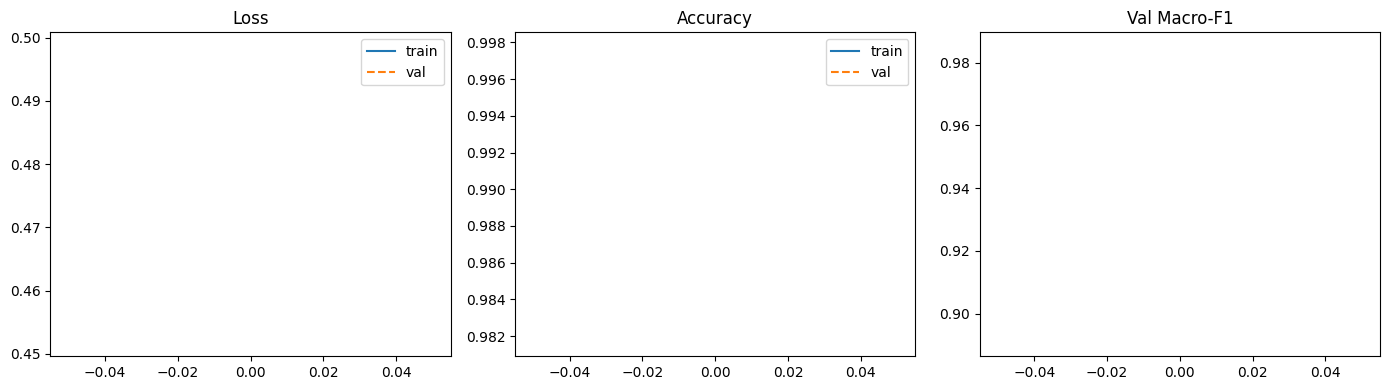

In [46]:
h = pd.DataFrame(history)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
axes[0].plot(h['epoch'], h['tr_loss'], label='train')
axes[0].plot(h['epoch'], h['vl_loss'], label='val', ls='--')
axes[0].set_title('Loss'); axes[0].legend()

axes[1].plot(h['epoch'], h['tr_acc'], label='train')
axes[1].plot(h['epoch'], h['vl_acc'], label='val', ls='--')
axes[1].set_title('Accuracy'); axes[1].legend()

axes[2].plot(h['epoch'], h['vl_f1'], color='green')
axes[2].set_title('Val Macro-F1')

plt.tight_layout()
plt.show()

In [52]:
unique_classes = set(te_labels) | set(te_preds)
print(f" siniflərin sayı: {len(unique_classes)}")
print(f" təqdim etdiyiniz adların (names) sayı: {len(names)}")

 siniflərin sayı: 6
 təqdim etdiyiniz adların (names) sayı: 7


In [53]:
ckpt = torch.load(save_path / 'best.pt', map_location=DEVICE)
model.load_state_dict(ckpt['state_dict'])

_, te_acc, te_preds, te_labels = evaluate(model, test_dl,criterion)
names = [id2label[i] for i in sorted(id2label)]

print(f'test accuracy : {te_acc:.4f}')
print(f'macro-F1      : {f1_score(te_labels, te_preds, average="macro"):.4f}')
print()
print(classification_report(
    te_labels,
    te_preds,
    labels=[0, 1, 2, 3, 4, 5, 6],
    target_names=names,
    digits=4
))

test accuracy : 0.9983
macro-F1      : 0.9521

                precision    recall  f1-score   support

   Accessories     0.9988    0.9947    0.9967      1691
       Apparel     0.9984    0.9997    0.9991      3209
      Footwear     0.9986    1.0000    0.9993      1383
    Free Items     1.0000    0.9375    0.9677        16
          Home     0.0000    0.0000    0.0000         0
 Personal Care     1.0000    1.0000    1.0000       361
Sporting Goods     0.6000    1.0000    0.7500         3

      accuracy                         0.9983      6663
     macro avg     0.7994    0.8474    0.8161      6663
  weighted avg     0.9985    0.9983    0.9984      6663



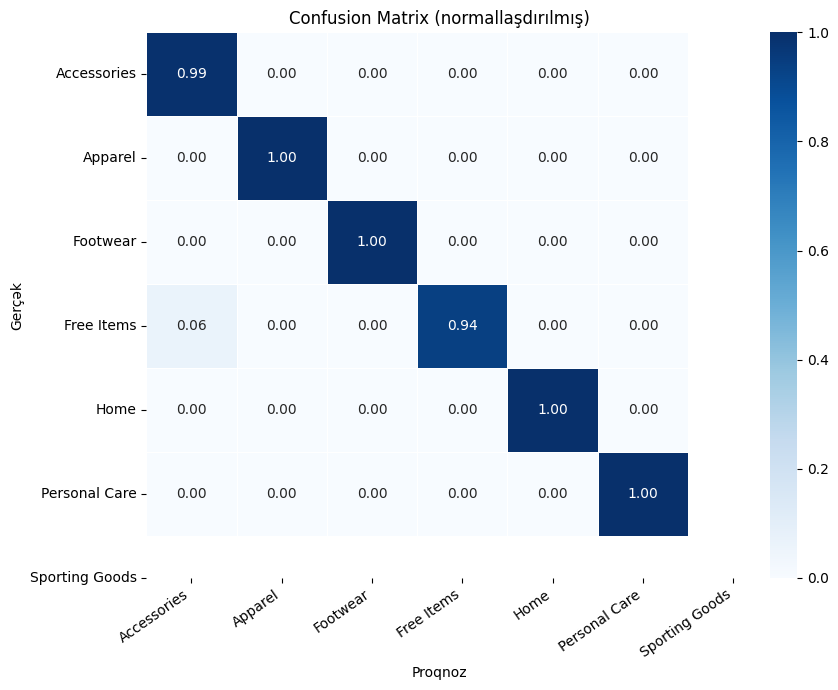

In [54]:
cm     = confusion_matrix(te_labels, te_preds)
cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(cm_pct, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=names, yticklabels=names, linewidths=0.4, ax=ax)
ax.set_xlabel('Proqnoz')
ax.set_ylabel('Gerçək')
ax.set_title('Confusion Matrix (normallaşdırılmış)')
plt.xticks(rotation=35, ha='right')
plt.tight_layout()
plt.show()

# Gradio Interaktiv Demo

In [102]:
import gradio as gr

infer_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(IMG_MEAN, IMG_STD),
])

COLOURS = ['Black','White','Blue','Red','Green','Grey','Navy Blue',
           'Pink','Brown','Yellow','Purple','Beige','Orange','Khaki']
SEASONS = ['Summer','Winter','Fall','Spring']

@torch.no_grad()
def predict(pil_img, product_name, article_type, colour, season):
    if pil_img is None or not product_name.strip():
        return {}
    img = infer_transform(pil_img.convert('RGB')).unsqueeze(0).to(DEVICE)
    text = build_text(product_name, article_type, colour, season)
    enc  = tokenizer(text, max_length=MAX_LEN, padding='max_length',
                     truncation=True, return_tensors='pt')
    ids  = enc['input_ids'].to(DEVICE)
    msk  = enc['attention_mask'].to(DEVICE)

    model.eval()
    logits = model(img, ids, msk)
    probs  = F.softmax(logits, -1).squeeze(0).cpu().numpy()
    return {id2label[i]: float(p) for i, p in enumerate(probs)}

demo = gr.Interface(
    fn=predict,
    inputs=[
        gr.Image(type='pil', label=' Məhsul şəkli'),
        gr.Textbox(label=' Məhsul adı', placeholder='Məs: Men\'s Slim Fit Jeans'),
        gr.Textbox(label='Növ', placeholder='Məs: Jeans'),
        gr.Dropdown(COLOURS, value='Black', label=' Rəng'),
        gr.Dropdown(SEASONS, value='Summer', label=' Mövsüm'),
    ],
    outputs=gr.Label(num_top_classes=NUM_CLASSES, label='Kateqoriya ehtimalları'),
    title=' Çox-Modal Məhsul Klassifikatoru',
    description='Şəkil + mətn məlumatlarını birləşdirərək kateqoriyanı təyin edir.',
    examples=[
        [None, "Men's Blue Slim Fit Jeans",    "Jeans",  "Blue",  "Fall"],
        [None, "Nike Air Max Running Shoes",   "Shoes",  "White", "Spring"],
        [None, "Women's Floral Summer Dress",  "Dress",  "Pink",  "Summer"],
        [None, "Leather Bifold Wallet",         "Wallet", "Black", "Winter"],
    ]
)

demo.launch(share=False, inbrowser=False)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
Note: opening Chrome Inspector may crash demo inside Colab notebooks.
* To create a public link, set `share=True` in `launch()`.


<IPython.core.display.Javascript object>

In [ ]:
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'  PyTorch: {torch.__version__}')
print(f'  Cihaz  : {DEVICE}')